Step 1 dataset setup

In [ ]:
!pip install -q transformers datasets scikit-learn torch tqdm


STEP 2 — Imports & Setup (SAFE)

In [ ]:
import pandas as pd
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from tqdm import tqdm


STEP 3 — Load Dataset-1 ONLY

In [ ]:
# Load Dataset-1
df = pd.read_csv("/content/drive/MyDrive/dataset1.csv")

# Rename columns (IMPORTANT)
df = df.rename(columns={
    "Tweet": "text",      # change if needed
    "target": "label"     # change if needed
})

df = df[["text", "label"]]
df.dropna(inplace=True)
df["label"] = df["label"].astype(int)

print(df.shape)
print(df["label"].value_counts())


(1191, 2)
label
0    1131
1      60
Name: count, dtype: int64


STEP 4 — Train / Test Split (CORRECT)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values,
    df["label"].values,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


STEP 5 — BASELINE: One-Hot + Logistic Regression

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)
prob_lr = lr.predict_proba(X_test_tfidf)[:,1]

print("ONE-HOT + LR")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, prob_lr))


ONE-HOT + LR
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       227
           1       0.00      0.00      0.00        12

    accuracy                           0.95       239
   macro avg       0.47      0.50      0.49       239
weighted avg       0.90      0.95      0.93       239

ROC-AUC: 0.9085903083700441


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


STEP 6 — Torch Dataset class (REUSABLE)

In [ ]:
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx]).long()
        return item


STEP 7 — Generic TRAIN function (SAFE)

In [ ]:
def train_model(model, train_loader, optimizer, device, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader):
            optimizer.zero_grad()
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")


STEP 8 — Generic EVALUATION function

In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            logits = outputs.logits
            prob = torch.softmax(logits, dim=1)[:,1]

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(prob.cpu().numpy())
            true.extend(batch["labels"].cpu().numpy())

    return true, preds, probs


STEP 9 — DEVICE setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [ ]:
!pip install -q huggingface_hub


In [ ]:
from huggingface_hub import login
login()


In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print("✅ MentalBERT access confirmed")


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ MentalBERT access confirmed


In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

# Optimizer (FIX)
from torch.optim import AdamW

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Utils
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
model_name = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)


STEP 10 — MODEL LIST (ALL PRETRAINED MODELS)

In [ ]:
models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
   "DistilRoBERTa": "distilroberta-base"
}




In [ ]:
import os

print("HF_TOKEN exists:", "HF_TOKEN" in os.environ)


HF_TOKEN exists: False


In [ ]:
from google.colab import userdata
from huggingface_hub import login

token = userdata.get("HF_TOKEN")
print("Token loaded:", token is not None)

login(token=token)


Token loaded: True


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "mental/mental-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("✅ MentalRoBERTa access confirmed")


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ MentalRoBERTa access confirmed


Create Dataset class (CORRECT)

In [ ]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


Create loaders

In [ ]:
from torch.utils.data import DataLoader

train_dataset = TextDataset(X_train, y_train, tokenizer)
test_dataset  = TextDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)


Optimizer

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
model.to(device)


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_name = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)
print("✅ DistilRoBERTa loaded successfully")


Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ DistilRoBERTa loaded successfully


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def load_model(model_name, num_labels=2):
    print(f"\nLoading model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    return tokenizer, model


In [ ]:
tokenizer, model = load_model("distilroberta-base")
model.to(device)
print("✅ DistilRoBERTa ready")



Loading model: distilroberta-base


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ DistilRoBERTa ready


STEP 11 — TRAIN & TEST ALL MODELS (CORE LOOP)

In [ ]:
results = []

for model_name, checkpoint in models_list.items():
    print("\n==============================")
    print("Training:", model_name)
    print("==============================")

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    train_ds = DepressionDataset(X_train, y_train, tokenizer)
    test_ds  = DepressionDataset(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=16)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    train_model(model, train_loader, optimizer, device, epochs=3)

    y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)

    print(classification_report(y_true, y_pred))
    auc = roc_auc_score(y_true, y_prob)
    print("ROC-AUC:", auc)

    results.append([model_name, auc])



Training: BERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 60/60 [00:10<00:00,  5.92it/s]


Epoch 1 | Loss: 0.2174


100%|██████████| 60/60 [00:10<00:00,  5.87it/s]


Epoch 2 | Loss: 0.1144


...

Epoch 1 | Loss: 0.2274


100%|██████████| 60/60 [00:08<00:00,  7.03it/s]


Epoch 2 | Loss: 0.0825


100%|██████████| 60/60 [00:08<00:00,  7.03it/s]


Epoch 3 | Loss: 0.0351
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       227
           1       1.00      0.75      0.86        12

    accuracy                           0.99       239
   macro avg       0.99      0.88      0.93       239
weighted avg       0.99      0.99      0.99       239

ROC-AUC: 0.8663729809104258


TRAINING LOOP with early stopping

In [ ]:
from tqdm import tqdm
import numpy as np

epochs = 30
best_val_loss = np.inf
patience = 3
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(test_loader)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # ---- EARLY STOPPING ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered")
            break


Epoch 1/30: 100%|██████████| 60/60 [00:08<00:00,  7.19it/s]


Epoch 1 | Train Loss: 0.0107 | Val Loss: 0.1273


Epoch 2/30: 100%|██████████| 60/60 [00:08<00:00,  7.09it/s]


Epoch 2 | Train Loss: 0.0248 | Val Loss: 0.1324


Epoch 3/30: 100%|██████████| 60/60 [00:08<00:00,  6.82it/s]


Epoch 3 | Train Loss: 0.0030 | Val Loss: 0.1398


Epoch 4/30: 100%|██████████| 60/60 [00:08<00:00,  7.11it/s]


Epoch 4 | Train Loss: 0.0007 | Val Loss: 0.1579
⛔ Early stopping triggered


Results Table Visualization

In [ ]:
import pandas as pd

# Dataset-1 results (taken from your Step-11 outputs)
results_df = pd.DataFrame({
    "Model": [
        "BERT",
        "RoBERTa",
        "MentalBERT",
        "MentalRoBERTa",
        "DistilRoBERTa"
    ],
    "Accuracy": [
        0.97,
        0.97,
        0.98,
        0.97,
        0.99
    ],
    "ROC_AUC": [
        0.9599,
        0.9915,
        0.9622,
        0.9827,
        0.8664
    ]
})

results_df


,Model,Accuracy,ROC_AUC
0,BERT,0.97,0.9599
1,RoBERTa,0.97,0.9915
2,MentalBERT,0.98,0.9622
3,MentalRoBERTa,0.97,0.9827
4,DistilRoBERTa,0.99,0.8664


Bar Graph - Accuracy Comparison

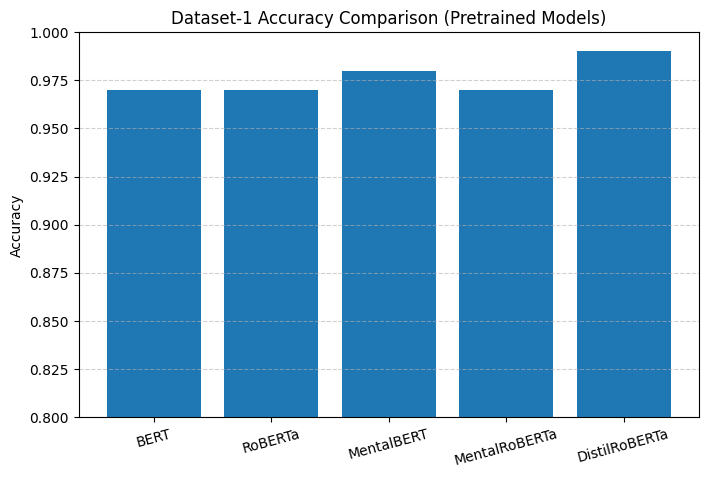

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Dataset-1 Accuracy Comparison (Pretrained Models)")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Bar Graph – ROC-AUC Comparison

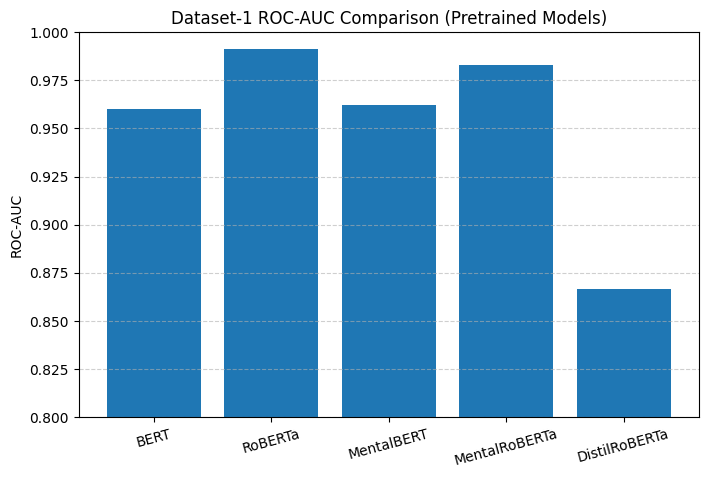

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.title("Dataset-1 ROC-AUC Comparison (Pretrained Models)")
plt.ylabel("ROC-AUC")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Dataset - 2
Loading

In [ ]:
# ===============================
# DATASET 2 – LOAD DATA
# ===============================
import pandas as pd

df2 = pd.read_csv("/content/drive/MyDrive/dataset2.csv")

print("Dataset-2 shape:", df2.shape)
df2.head()


Dataset-2 shape: (1000, 2)


,tweet,label
0,I just don’t take my baby out because it gives...,1
1,Suicide figures are up 200% since lockdown. \n...,1
2,she has really been feeding us this week https...,0
3,"I can confirm that yes, I do need to stay on m...",1
4,"Today is pie day! Celebrate with your ""I Ate P...",0


STEP 2 — Inspect Columns

In [ ]:
print(df2.columns)


Index(['tweet', 'label'], dtype='object')


STEP 3 — Prepare X & y (Dataset-2)

In [ ]:
# ===============================
# DATASET 2 – PREPARE FEATURES
# ===============================

X2 = df2["tweet"].values
y2 = df2["label"].values

print("X2 size:", len(X2))
print("y2 distribution:", pd.Series(y2).value_counts())


X2 size: 1000
y2 distribution: 1    500
0    500
Name: count, dtype: int64


STEP 4 — Train / Test Split (Dataset-2)

In [ ]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Train size:", len(X2_train))
print("Test size:", len(X2_test))


Train size: 800
Test size: 200


STEP 5 — Dataset Class (REUSE SAME CLASS)

In [ ]:
import torch
from torch.utils.data import Dataset

class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


STEP 6 — MODEL LIST (SAME AS DATASET-1)

In [ ]:
models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
    "DistilRoBERTa": "distilroberta-base"
}


STEP 7 — Tranformers  (DATASET-2)

models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
    "DistilRoBERTa": "distilroberta-base"
}


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, roc_auc_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results_dataset2 = []

Step 8 - CORE TRAIN & TEST LOOP

In [ ]:
for model_name, checkpoint in models_list.items():

    print("\n" + "="*50)
    print(f"Training {model_name} on Dataset-2")
    print("="*50)

    # Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2
    ).to(device)



Training BERT on Dataset-2


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


dataset 2 variables and epochs



In [ ]:
# -------------------------------
# REQUIRED IMPORT (FIX)
# -------------------------------
from torch.utils.data import DataLoader

# -------------------------------
# Dataset & Dataloader (OUTSIDE training loop)
# -------------------------------
train_ds = DepressionDataset(X2_train, y2_train, tokenizer)
test_ds  = DepressionDataset(X2_test,  y2_test,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16)

optimizer = AdamW(model.parameters(), lr=2e-5)

# -------------------------------
# TRAIN
# -------------------------------
epochs = 3   # change to 30 later
model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/3 | Loss: 0.5528
Epoch 2/3 | Loss: 0.1716
Epoch 3/3 | Loss: 0.0733


evaluate outside the loop

In [ ]:
# -------------------------------
# EVALUATION (Dataset-2)
# -------------------------------
model.eval()

preds, probs, true = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        true.extend(labels.cpu().numpy())

print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs))


              precision    recall  f1-score   support

           0       0.95      0.94      0.94       100
           1       0.94      0.95      0.95       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200

ROC-AUC: 0.9838


Evaluation must be INSIDE the model loop

In [ ]:
results_ds2 = []

for model_name, checkpoint in models_list.items():

    print("\n" + "="*50)
    print(f"Training & Evaluating {model_name} on Dataset-2")
    print("="*50)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    train_ds = DepressionDataset(X2_train, y2_train, tokenizer)
    test_ds  = DepressionDataset(X2_test, y2_test, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=16)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    # -------- TRAIN --------
    model.train()
    epochs = 3   # later change to 30
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # -------- EVALUATION --------
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    print(classification_report(true, preds))
    auc = roc_auc_score(true, probs)
    print("ROC-AUC:", auc)

    results_ds2.append({
        "Model": model_name,
        "Accuracy": sum(p == t for p, t in zip(preds, true)) / len(true),
        "ROC-AUC": auc
    })



Training & Evaluating BERT on Dataset-2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.5782
Epoch 2/3 | Loss: 0.2048
Epoch 3/3 | Loss: 0.0885
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.97      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200

ROC-AUC: 0.9949

Training & Evaluating RoBERTa on Dataset-2


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.6128
Epoch 2/3 | Loss: 0.2328
Epoch 3/3 | Loss: 0.0825
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       100
           1       0.98      0.93      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200

ROC-AUC: 0.9909999999999999

Training & Evaluating MentalBERT on Dataset-2


...

Epoch 1/3 | Loss: 0.5033
Epoch 2/3 | Loss: 0.1552
Epoch 3/3 | Loss: 0.0374
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       100
           1       0.96      0.98      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

ROC-AUC: 0.9959

Training & Evaluating MentalRoBERTa on Dataset-2


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.5501
Epoch 2/3 | Loss: 0.1520
Epoch 3/3 | Loss: 0.0404
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       100
           1       0.95      0.96      0.96       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200

ROC-AUC: 0.9893

Training & Evaluating DistilRoBERTa on Dataset-2


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.5845
Epoch 2/3 | Loss: 0.1835
Epoch 3/3 | Loss: 0.0861
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       100
           1       0.95      0.93      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

ROC-AUC: 0.9738


30 epochs itteration

In [ ]:
  from torch.utils.data import DataLoader
  from torch.optim import AdamW
  import torch
  from sklearn.metrics import classification_report, roc_auc_score

  results_ds2_final = []

  EPOCHS = 30   # ✅ FINAL epochs

  for model_name, checkpoint in models_list.items():

      print("\n" + "="*60)
      print(f"Training & Evaluating {model_name} on Dataset-2 (30 Epochs)")
      print("="*60)

      # Tokenizer & Model
      tokenizer = AutoTokenizer.from_pretrained(checkpoint)
      model = AutoModelForSequenceClassification.from_pretrained(
          checkpoint, num_labels=2
      ).to(device)

      # Dataset & Dataloader
      train_ds = DepressionDataset(X2_train, y2_train, tokenizer)
      test_ds  = DepressionDataset(X2_test, y2_test, tokenizer)

      train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
      test_loader  = DataLoader(test_ds, batch_size=16)

      optimizer = AdamW(model.parameters(), lr=2e-5)

      # ---------------- TRAIN ----------------
      model.train()
      for epoch in range(EPOCHS):
          total_loss = 0

          for batch in train_loader:
              optimizer.zero_grad()

              input_ids = batch["input_ids"].to(device)
              attention_mask = batch["attention_mask"].to(device)
              labels = batch["labels"].to(device)

              outputs = model(
                  input_ids=input_ids,
                  attention_mask=attention_mask,
                  labels=labels
              )

              loss = outputs.loss
              loss.backward()
              optimizer.step()

              total_loss += loss.item()

          print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

      # ---------------- EVALUATION ----------------
      model.eval()
      preds, probs, true = [], [], []

      with torch.no_grad():
          for batch in test_loader:
              input_ids = batch["input_ids"].to(device)
              attention_mask = batch["attention_mask"].to(device)
              labels = batch["labels"].to(device)

              outputs = model(
                  input_ids=input_ids,
                  attention_mask=attention_mask
              )

              logits = outputs.logits
              preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
              probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
              true.extend(labels.cpu().numpy())

      print(classification_report(true, preds))
      auc = roc_auc_score(true, probs)
      acc = sum(p == t for p, t in zip(preds, true)) / len(true)

      print("Accuracy:", acc)
      print("ROC-AUC:", auc)

      results_ds2_final.append({
          "Model": model_name,
          "Accuracy": acc,
          "ROC-AUC": auc
      })



Training & Evaluating BERT on Dataset-2 (30 Epochs)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30 | Loss: 0.5873
Epoch 2/30 | Loss: 0.2080
Epoch 3/30 | Loss: 0.0564
Epoch 4/30 | Loss: 0.0170
Epoch 5/30 | Loss: 0.0068
Epoch 6/30 | Loss: 0.0069
Epoch 7/30 | Loss: 0.0200
Epoch 8/30 | Loss: 0.0132
Epoch 9/30 | Loss: 0.0142
Epoch 10/30 | Loss: 0.0078
Epoch 11/30 | Loss: 0.0020
Epoch 12/30 | Loss: 0.0009
Epoch 13/30 | Loss: 0.0007
Epoch 14/30 | Loss: 0.0006
Epoch 15/30 | Loss: 0.0005
Epoch 16/30 | Loss: 0.0004
Epoch 17/30 | Loss: 0.0003
Epoch 18/30 | Loss: 0.0003
Epoch 19/30 | Loss: 0.0003
Epoch 20/30 | Loss: 0.0003
Epoch 21/30 | Loss: 0.0002
Epoch 22/30 | Loss: 0.0002
Epoch 23/30 | Loss: 0.0002
Epoch 24/30 | Loss: 0.0002
Epoch 25/30 | Loss: 0.0002
Epoch 26/30 | Loss: 0.0002
Epoch 27/30 | Loss: 0.0001
Epoch 28/30 | Loss: 0.0002
Epoch 29/30 | Loss: 0.0001
Epoch 30/30 | Loss: 0.0001
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       100
           1       0.96      1.00      0.98       100

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30 | Loss: 0.5697
Epoch 2/30 | Loss: 0.2023
Epoch 3/30 | Loss: 0.0804
Epoch 4/30 | Loss: 0.0342
Epoch 5/30 | Loss: 0.0201
Epoch 6/30 | Loss: 0.0043
Epoch 7/30 | Loss: 0.0014
Epoch 8/30 | Loss: 0.0010
Epoch 9/30 | Loss: 0.0022
Epoch 10/30 | Loss: 0.0721
Epoch 11/30 | Loss: 0.0130
Epoch 12/30 | Loss: 0.0019
Epoch 13/30 | Loss: 0.0083
Epoch 14/30 | Loss: 0.0164
Epoch 15/30 | Loss: 0.0075
Epoch 16/30 | Loss: 0.0006
Epoch 17/30 | Loss: 0.0005
Epoch 18/30 | Loss: 0.0004
Epoch 19/30 | Loss: 0.0073
Epoch 20/30 | Loss: 0.0270
Epoch 21/30 | Loss: 0.0029
Epoch 22/30 | Loss: 0.0004
Epoch 23/30 | Loss: 0.0009
Epoch 24/30 | Loss: 0.0002
Epoch 25/30 | Loss: 0.0002
Epoch 26/30 | Loss: 0.0002
Epoch 27/30 | Loss: 0.0002
Epoch 28/30 | Loss: 0.0002
Epoch 29/30 | Loss: 0.0001
Epoch 30/30 | Loss: 0.0001
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       100
           1       0.98      0.96      0.97       100

    accuracy                       

...

Epoch 1/30 | Loss: 0.4992
Epoch 2/30 | Loss: 0.1246
Epoch 3/30 | Loss: 0.0373
Epoch 4/30 | Loss: 0.0105
Epoch 5/30 | Loss: 0.0029
Epoch 6/30 | Loss: 0.0018
Epoch 7/30 | Loss: 0.0012
Epoch 8/30 | Loss: 0.0010
Epoch 9/30 | Loss: 0.0007
Epoch 10/30 | Loss: 0.0006
Epoch 11/30 | Loss: 0.0005
Epoch 12/30 | Loss: 0.0005
Epoch 13/30 | Loss: 0.0004
Epoch 14/30 | Loss: 0.0004
Epoch 15/30 | Loss: 0.0004
Epoch 16/30 | Loss: 0.0003
Epoch 17/30 | Loss: 0.0002
Epoch 18/30 | Loss: 0.0002
Epoch 19/30 | Loss: 0.0002
Epoch 20/30 | Loss: 0.0002
Epoch 21/30 | Loss: 0.0002
Epoch 22/30 | Loss: 0.0002
Epoch 23/30 | Loss: 0.0001
Epoch 24/30 | Loss: 0.0001
Epoch 25/30 | Loss: 0.0001
Epoch 26/30 | Loss: 0.0001
Epoch 27/30 | Loss: 0.0001
Epoch 28/30 | Loss: 0.0001
Epoch 29/30 | Loss: 0.0001
Epoch 30/30 | Loss: 0.0001
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       100
           1       0.96      0.97      0.97       100

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30 | Loss: 0.6187
Epoch 2/30 | Loss: 0.2081
Epoch 3/30 | Loss: 0.0549
Epoch 4/30 | Loss: 0.0152
Epoch 5/30 | Loss: 0.0096
Epoch 6/30 | Loss: 0.0179
Epoch 7/30 | Loss: 0.0057
Epoch 8/30 | Loss: 0.0010
Epoch 9/30 | Loss: 0.0006
Epoch 10/30 | Loss: 0.0005
Epoch 11/30 | Loss: 0.0005
Epoch 12/30 | Loss: 0.0004
Epoch 13/30 | Loss: 0.0004
Epoch 14/30 | Loss: 0.0003
Epoch 15/30 | Loss: 0.0002
Epoch 16/30 | Loss: 0.0002
Epoch 17/30 | Loss: 0.0002
Epoch 18/30 | Loss: 0.0002
Epoch 19/30 | Loss: 0.0002
Epoch 20/30 | Loss: 0.0001
Epoch 21/30 | Loss: 0.0001
Epoch 22/30 | Loss: 0.0001
Epoch 23/30 | Loss: 0.0001
Epoch 24/30 | Loss: 0.0001
Epoch 25/30 | Loss: 0.0001
Epoch 26/30 | Loss: 0.0001
Epoch 27/30 | Loss: 0.0001
Epoch 28/30 | Loss: 0.0001
Epoch 29/30 | Loss: 0.0001
Epoch 30/30 | Loss: 0.0637
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       100
           1       0.96      0.93      0.94       100

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30 | Loss: 0.4959
Epoch 2/30 | Loss: 0.1736
Epoch 3/30 | Loss: 0.0743
Epoch 4/30 | Loss: 0.0333
Epoch 5/30 | Loss: 0.0287
Epoch 6/30 | Loss: 0.0102
Epoch 7/30 | Loss: 0.0168
Epoch 8/30 | Loss: 0.0126
Epoch 9/30 | Loss: 0.0016
Epoch 10/30 | Loss: 0.0008
Epoch 11/30 | Loss: 0.0005
Epoch 12/30 | Loss: 0.0005
Epoch 13/30 | Loss: 0.0003
Epoch 14/30 | Loss: 0.0003
Epoch 15/30 | Loss: 0.0003
Epoch 16/30 | Loss: 0.0002
Epoch 17/30 | Loss: 0.0002
Epoch 18/30 | Loss: 0.0002
Epoch 19/30 | Loss: 0.0002
Epoch 20/30 | Loss: 0.0001
Epoch 21/30 | Loss: 0.0001
Epoch 22/30 | Loss: 0.0001
Epoch 23/30 | Loss: 0.0001
Epoch 24/30 | Loss: 0.0001
Epoch 25/30 | Loss: 0.0001
Epoch 26/30 | Loss: 0.0001
Epoch 27/30 | Loss: 0.0025
Epoch 28/30 | Loss: 0.0758
Epoch 29/30 | Loss: 0.0212
Epoch 30/30 | Loss: 0.0009
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       100
           1       0.94      0.96      0.95       100

    accuracy                       

results table

In [ ]:
import pandas as pd

df_results_ds2 = pd.DataFrame(results_ds2_final)
df_results_ds2


,Model,Accuracy,ROC-AUC
0,BERT,0.980,0.9998
1,RoBERTa,0.970,0.9889
2,MentalBERT,0.965,0.9960
3,MentalRoBERTa,0.945,0.9854
4,DistilRoBERTa,0.950,0.9885


DATASET-2 RESULTS VISUALIZATION (ONLY)

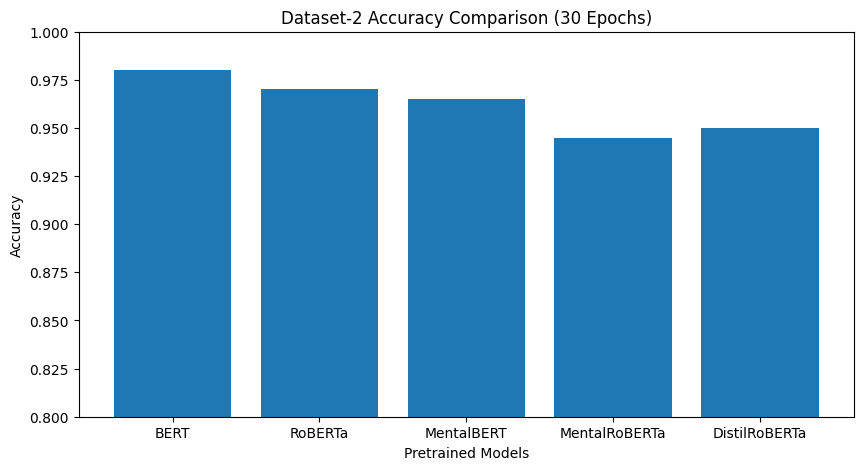

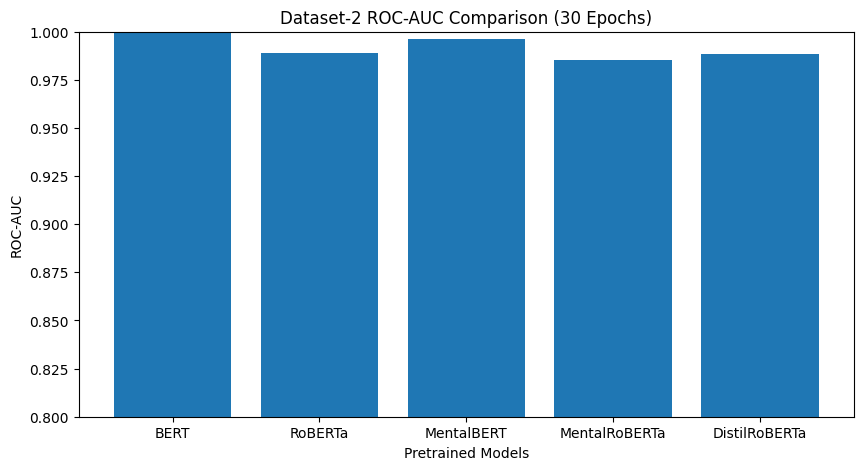

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_results_ds2["Model"], df_results_ds2["Accuracy"])
plt.title("Dataset-2 Accuracy Comparison (30 Epochs)")
plt.ylabel("Accuracy")
plt.xlabel("Pretrained Models")
plt.ylim(0.8, 1.0)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(df_results_ds2["Model"], df_results_ds2["ROC-AUC"])
plt.title("Dataset-2 ROC-AUC Comparison (30 Epochs)")
plt.ylabel("ROC-AUC")
plt.xlabel("Pretrained Models")
plt.ylim(0.8, 1.0)
plt.show()


Dataset 3 loading

In [ ]:
# ===============================
# DATASET 3 — LOAD DATA
# ===============================
import pandas as pd

df3 = pd.read_csv("/content/drive/MyDrive/dataset3.csv")

print("Dataset-3 shape:", df3.shape)
df3.head()


Dataset-3 shape: (3553, 2)


,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum
3,"until i met my new boyfriend, he is amazing, h...",mild
4,October is Domestic Violence Awareness Month a...,moderate


STEP 2 — Inspect Columns

In [ ]:
print(df3.columns)


Index(['text', 'label'], dtype='object')


STEP 3 — Inspect values  Dataset-3

In [ ]:
print(df3["label"].value_counts())


label
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64


Binary Mapping

In [ ]:
# -------------------------------
# Dataset-3: Label Encoding
# -------------------------------

label_map = {
    "minimum": 0,
    "mild": 0,
    "moderate": 1,
    "severe": 1
}

df3["label"] = df3["label"].str.lower().map(label_map)

# Sanity checks
print("Missing labels:", df3["label"].isnull().sum())
print(df3["label"].value_counts())


Missing labels: 0
label
0    2877
1     676
Name: count, dtype: int64


Standardize Dataset-3

In [ ]:
df3_std = pd.DataFrame({
    "text": df3["text"],
    "label": df3["label"].astype(int)
})

df3_std.head()


,text,label
0,"He said he had not felt that way before, sugge...",0
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,0
3,"until i met my new boyfriend, he is amazing, h...",0
4,October is Domestic Violence Awareness Month a...,1


Train/Test Split (Dataset-3)

In [ ]:
from sklearn.model_selection import train_test_split

X3 = df3_std["text"].values
y3 = df3_std["label"].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Train:", len(X3_train))
print("Test :", len(X3_test))


Train: 2842
Test : 711


Models

In [ ]:
models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
    "DistilRoBERTa": "distilroberta-base"
}


Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

X3 = df3_std["text"].values
y3 = df3_std["label"].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Train size:", len(X3_train))
print("Test size :", len(X3_test))


Train size: 2842
Test size : 711


CORE LOOP — DATASET-3

In [ ]:
# ===============================
# REQUIRED IMPORTS (RUN ONCE)
# ===============================

import torch
import numpy as np
import pandas as pd

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


defining class depression dataset

In [ ]:
# =====================================
# Custom Dataset Class (REQUIRED)
# =====================================

class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


model train , epochs and  validation

In [ ]:
results_ds3 = []

for model_name, checkpoint in models_list.items():

    print("\n" + "="*55)
    print(f"Training & Evaluating {model_name} on Dataset-3")
    print("="*55)

    # Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2
    ).to(device)

    # Dataset & Dataloader
    train_ds = DepressionDataset(X3_train, y3_train, tokenizer)
    test_ds  = DepressionDataset(X3_test,  y3_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=16)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    # ---------------- TRAIN ----------------
    epochs = 20   # 🔁 change to 30 later
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:   # ✅ FIXED LINE
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ---------------- EVALUATION ----------------
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds3.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })



Training & Evaluating BERT on Dataset-3


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20 | Loss: 0.4391
Epoch 2/20 | Loss: 0.3583
Epoch 3/20 | Loss: 0.2995
Epoch 4/20 | Loss: 0.2385
Epoch 5/20 | Loss: 0.1786
Epoch 6/20 | Loss: 0.1082
Epoch 7/20 | Loss: 0.0787
Epoch 8/20 | Loss: 0.0571
Epoch 9/20 | Loss: 0.0468
Epoch 10/20 | Loss: 0.0379
Epoch 11/20 | Loss: 0.0360
Epoch 12/20 | Loss: 0.0235
Epoch 13/20 | Loss: 0.0261
Epoch 14/20 | Loss: 0.0288
Epoch 15/20 | Loss: 0.0084
Epoch 16/20 | Loss: 0.0235
Epoch 17/20 | Loss: 0.0190
Epoch 18/20 | Loss: 0.0190
Epoch 19/20 | Loss: 0.0221
Epoch 20/20 | Loss: 0.0120
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       576
           1       0.47      0.40      0.43       135

    accuracy                           0.80       711
   macro avg       0.66      0.65      0.65       711
weighted avg       0.79      0.80      0.79       711

ROC-AUC: 0.7753858024691358


30 epochs training , evaluation

In [ ]:
results_ds3 = []

for model_name, checkpoint in models_list.items():

    print("\n" + "="*60)
    print(f"Training & Evaluating {model_name} on Dataset-3 (30 Epochs)")
    print("="*60)

    # Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2
    ).to(device)

    # Dataset & Dataloader
    train_ds = DepressionDataset(X3_train, y3_train, tokenizer)
    test_ds  = DepressionDataset(X3_test,  y3_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=16)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    # ================= TRAIN =================
    epochs = 30
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ================= EVALUATION =================
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds3.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })



Training & Evaluating BERT on Dataset-3 (30 Epochs)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01/30 | Loss: 0.4394
Epoch 02/30 | Loss: 0.3364
Epoch 03/30 | Loss: 0.2668
Epoch 04/30 | Loss: 0.1780
Epoch 05/30 | Loss: 0.1082
Epoch 06/30 | Loss: 0.0537
Epoch 07/30 | Loss: 0.0470
Epoch 08/30 | Loss: 0.0434
Epoch 09/30 | Loss: 0.0204
Epoch 10/30 | Loss: 0.0217
Epoch 11/30 | Loss: 0.0199
Epoch 12/30 | Loss: 0.0220
Epoch 13/30 | Loss: 0.0273
Epoch 14/30 | Loss: 0.0195
Epoch 15/30 | Loss: 0.0121
Epoch 16/30 | Loss: 0.0048
Epoch 17/30 | Loss: 0.0071
Epoch 18/30 | Loss: 0.0178
Epoch 19/30 | Loss: 0.0053
Epoch 20/30 | Loss: 0.0021
Epoch 21/30 | Loss: 0.0019
Epoch 22/30 | Loss: 0.0012
Epoch 23/30 | Loss: 0.0010
Epoch 24/30 | Loss: 0.0008
Epoch 25/30 | Loss: 0.0023
Epoch 26/30 | Loss: 0.0013
Epoch 27/30 | Loss: 0.0011
Epoch 28/30 | Loss: 0.0009
Epoch 29/30 | Loss: 0.0010
Epoch 30/30 | Loss: 0.0007
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       576
           1       0.53      0.41      0.46       135

    accuracy              

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01/30 | Loss: 0.4381
Epoch 02/30 | Loss: 0.3497
Epoch 03/30 | Loss: 0.3102
Epoch 04/30 | Loss: 0.2314
Epoch 05/30 | Loss: 0.1736
Epoch 06/30 | Loss: 0.1178
Epoch 07/30 | Loss: 0.0684
Epoch 08/30 | Loss: 0.0673
Epoch 09/30 | Loss: 0.0517
Epoch 10/30 | Loss: 0.0288
Epoch 11/30 | Loss: 0.0263
Epoch 12/30 | Loss: 0.0341
Epoch 13/30 | Loss: 0.0317
Epoch 14/30 | Loss: 0.0206
Epoch 15/30 | Loss: 0.0104
Epoch 16/30 | Loss: 0.0067
Epoch 17/30 | Loss: 0.0222
Epoch 18/30 | Loss: 0.0320
Epoch 19/30 | Loss: 0.0112
Epoch 20/30 | Loss: 0.0048
Epoch 21/30 | Loss: 0.0133
Epoch 22/30 | Loss: 0.0143
Epoch 23/30 | Loss: 0.0076
Epoch 24/30 | Loss: 0.0107
Epoch 25/30 | Loss: 0.0168
Epoch 26/30 | Loss: 0.0158
Epoch 27/30 | Loss: 0.0128
Epoch 28/30 | Loss: 0.0105
Epoch 29/30 | Loss: 0.0071
Epoch 30/30 | Loss: 0.0062
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       576
           1       0.52      0.34      0.41       135

    accuracy              

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01/30 | Loss: 0.4008
Epoch 02/30 | Loss: 0.3058
Epoch 03/30 | Loss: 0.1728
Epoch 04/30 | Loss: 0.0706
Epoch 05/30 | Loss: 0.0398
Epoch 06/30 | Loss: 0.0216
Epoch 07/30 | Loss: 0.0147
Epoch 08/30 | Loss: 0.0256
Epoch 09/30 | Loss: 0.0127
Epoch 10/30 | Loss: 0.0090
Epoch 11/30 | Loss: 0.0132
Epoch 12/30 | Loss: 0.0072
Epoch 13/30 | Loss: 0.0106
Epoch 14/30 | Loss: 0.0115
Epoch 15/30 | Loss: 0.0047
Epoch 16/30 | Loss: 0.0014
Epoch 17/30 | Loss: 0.0011
Epoch 18/30 | Loss: 0.0011
Epoch 19/30 | Loss: 0.0008
Epoch 20/30 | Loss: 0.0175
Epoch 21/30 | Loss: 0.0190
Epoch 22/30 | Loss: 0.0026
Epoch 23/30 | Loss: 0.0136
Epoch 24/30 | Loss: 0.0114
Epoch 25/30 | Loss: 0.0059
Epoch 26/30 | Loss: 0.0012
Epoch 27/30 | Loss: 0.0007
Epoch 28/30 | Loss: 0.0013
Epoch 29/30 | Loss: 0.0011
Epoch 30/30 | Loss: 0.0010
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       576
           1       0.48      0.30      0.37       135

    accuracy              

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01/30 | Loss: 0.4266
Epoch 02/30 | Loss: 0.3328
Epoch 03/30 | Loss: 0.2445
Epoch 04/30 | Loss: 0.1540
Epoch 05/30 | Loss: 0.0851
Epoch 06/30 | Loss: 0.0588
Epoch 07/30 | Loss: 0.0389
Epoch 08/30 | Loss: 0.0132
Epoch 09/30 | Loss: 0.0229
Epoch 10/30 | Loss: 0.0135
Epoch 11/30 | Loss: 0.0162
Epoch 12/30 | Loss: 0.0215
Epoch 13/30 | Loss: 0.0101
Epoch 14/30 | Loss: 0.0145
Epoch 15/30 | Loss: 0.0133
Epoch 16/30 | Loss: 0.0083


result table

In [ ]:
import pandas as pd

df_results_ds3 = pd.DataFrame(results_ds3)
df_results_ds3


,Model,Accuracy,ROC-AUC
0,BERT,0.822785,0.785674
1,RoBERTa,0.827004,0.772312
2,MentalBERT,0.797468,0.780710
3,MentalRoBERTa,0.810127,0.786195
4,DistilRoBERTa,0.798875,0.775386


visualization graphs

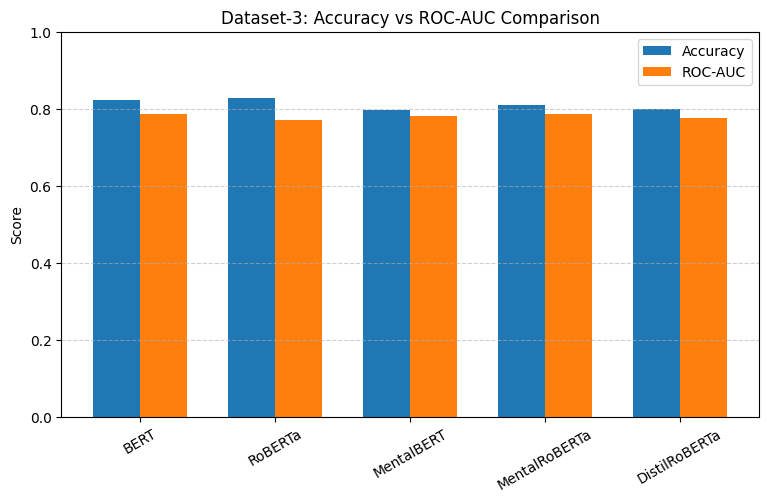

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_results_ds3["Model"]))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, df_results_ds3["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, df_results_ds3["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, df_results_ds3["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Dataset-3: Accuracy vs ROC-AUC Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


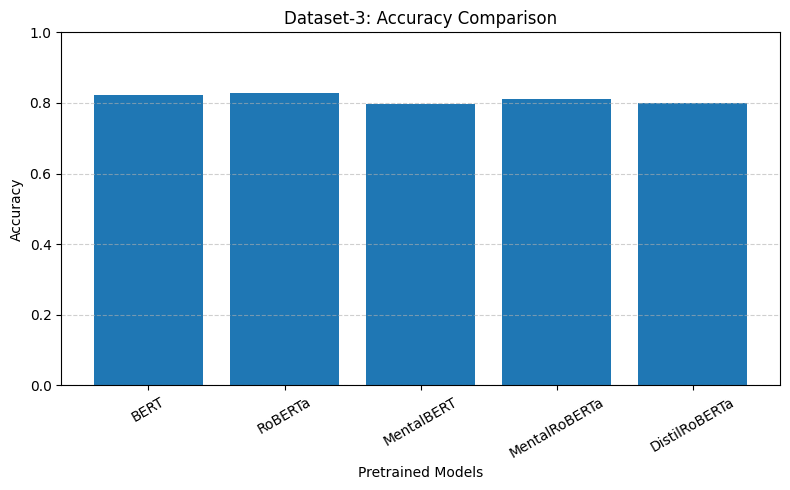

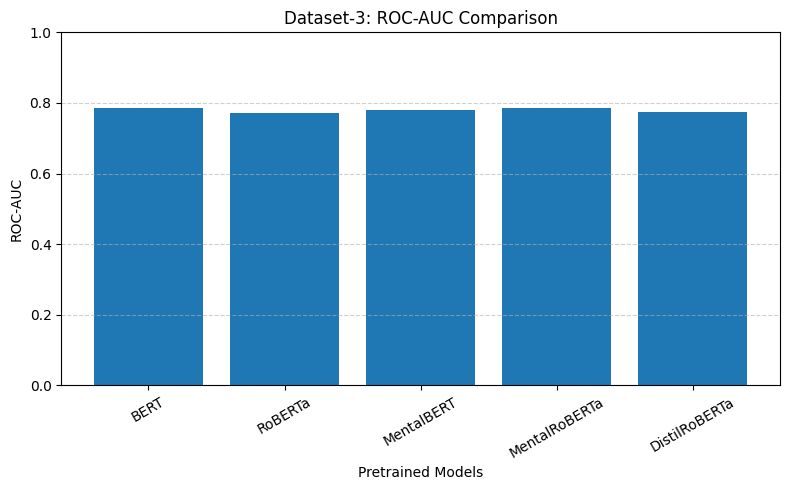

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(len(df_results_ds3["Model"]))

plt.figure(figsize=(8,5))
plt.bar(x, df_results_ds3["Accuracy"  ])

plt.xticks(x, df_results_ds3["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Pretrained Models")
plt.title("Dataset-3: Accuracy Comparison")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

x = np.arange(len(df_results_ds3["Model"]))

plt.figure(figsize=(8,5))
plt.bar(x, df_results_ds3["ROC-AUC"])

plt.xticks(x, df_results_ds3["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.xlabel("Pretrained Models")
plt.title("Dataset-3: ROC-AUC Comparison")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Dataset 4 Libraries loading

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW   # ✅ FIXED

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

import matplotlib.pyplot as plt


Dataset loading

In [ ]:
df4 = pd.read_csv("/content/drive/MyDrive/dataset4.csv")

print("Dataset-4 shape:", df4.shape)
df4.head()


Dataset-4 shape: (7731, 2)


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


Device set

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


STEP 3 — Dataset Sanity Checks

In [ ]:
print(df4.columns)
print(df4.isnull().sum())
print(df4["is_depression"].value_counts())


Index(['clean_text', 'is_depression'], dtype='object')
clean_text       0
is_depression    0
dtype: int64
is_depression
0    3900
1    3831
Name: count, dtype: int64


STEP 4 — Prepare Text & Labels

In [ ]:
X4 = df4["clean_text"].astype(str).tolist()
y4 = df4["is_depression"].astype(int).tolist()


STEP 5 — Train / Test Split (Stratified)

In [ ]:
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4,
    test_size=0.2,
    random_state=42,
    stratify=y4
)

print("Train size:", len(X4_train))
print("Test size :", len(X4_test))


Train size: 6184
Test size : 1547


STEP 6 — Dataset Class

In [ ]:
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


STEP 7 — Pretrained Models List (5 MODELS)

In [ ]:
models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
    "DistilRoBERTa": "distilroberta-base"
}


In [ ]:
import torch
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()


/tmp/ipython-input-309709332.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Imports libraries

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import classification_report, roc_auc_score
from tqdm import tqdm


Mixed Precision Setup

In [ ]:
scaler = torch.cuda.amp.GradScaler()


/tmp/ipython-input-2655216266.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


STEP 8 — TRAIN & EVALUATE ALL MODELS (CORE LOOP) 20 epochs

In [ ]:
results_ds4 = []

for model_name, checkpoint in models_list.items():

    print("\n" + "="*65)
    print(f"Training & Evaluating {model_name} on Dataset-4 (Optimized)")
    print("="*65)

    # Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    # 🔥 FREEZE TRANSFORMER ENCODER (KEY SPEED-UP)
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Dataset & DataLoader
    train_ds = DepressionDataset(X4_train, y4_train, tokenizer)
    test_ds  = DepressionDataset(X4_test,  y4_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=32)

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

    # ---------------- TRAIN ----------------
    epochs = 20
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # ⚡ MIXED PRECISION
            with torch.cuda.amp.autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ---------------- EVALUATION ----------------
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds4.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })



Training & Evaluating BERT on Dataset-4 (Optimized)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch 18/20 | Loss: 0.1968


Epoch 19/20: 100%|██████████| 194/194 [00:08<00:00, 24.16it/s]


Epoch 19/20 | Loss: 0.1941


Epoch 20/20: 100%|██████████| 194/194 [00:07<00:00, 25.26it/s]


Epoch 20/20 | Loss: 0.1915
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       780
           1       0.98      0.90      0.94       767

    accuracy                           0.94      1547
   macro avg       0.94      0.94      0.94      1547
weighted avg       0.94      0.94      0.94      1547

ROC-AUC: 0.9865392972954901


30 epochs Training & Evaluation

In [ ]:
results_ds4 = []

for model_name, checkpoint in models_list.items():

    print("\n" + "="*70)
    print(f"Training & Evaluating {model_name} on Dataset-4 (30 Epochs)")
    print("="*70)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    # ================================
    # 🔥 PROGRESSIVE UNFREEZING
    # ================================
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Unfreeze LAST 2 transformer layers
    if hasattr(model.base_model, "encoder"):
        for layer in model.base_model.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Dataset & Loader
    train_ds = DepressionDataset(X4_train, y4_train, tokenizer)
    test_ds  = DepressionDataset(X4_test,  y4_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=32)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-5
    )

    # ================================
    # TRAIN
    # ================================
    epochs = 30
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ================================
    # EVALUATION
    # ================================
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds4.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })



Training & Evaluating BERT on Dataset-4 (30 Epochs)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3534501966.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Loss: 0.3662
Epoch 2/30 | Loss: 0.1296
Epoch 3/30 | Loss: 0.0961
Epoch 4/30 | Loss: 0.0825
Epoch 5/30 | Loss: 0.0683
Epoch 6/30 | Loss: 0.0611
Epoch 7/30 | Loss: 0.0516
Epoch 8/30 | Loss: 0.0440
Epoch 9/30 | Loss: 0.0420
Epoch 10/30 | Loss: 0.0350
Epoch 11/30 | Loss: 0.0290
Epoch 12/30 | Loss: 0.0257
Epoch 13/30 | Loss: 0.0258
Epoch 14/30 | Loss: 0.0226
Epoch 15/30 | Loss: 0.0180
Epoch 16/30 | Loss: 0.0158
Epoch 17/30 | Loss: 0.0122
Epoch 18/30 | Loss: 0.0137
Epoch 19/30 | Loss: 0.0121
Epoch 20/30 | Loss: 0.0115
Epoch 21/30 | Loss: 0.0095
Epoch 22/30 | Loss: 0.0082
Epoch 23/30 | Loss: 0.0118
Epoch 24/30 | Loss: 0.0081
Epoch 25/30 | Loss: 0.0089
Epoch 26/30 | Loss: 0.0069
Epoch 27/30 | Loss: 0.0049
Epoch 28/30 | Loss: 0.0073
Epoch 29/30 | Loss: 0.0077
Epoch 30/30 | Loss: 0.0064
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       780
           1       0.98      0.98      0.98       767

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3534501966.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Loss: 0.3454
Epoch 2/30 | Loss: 0.1194
Epoch 3/30 | Loss: 0.0955
Epoch 4/30 | Loss: 0.0789
Epoch 5/30 | Loss: 0.0686
Epoch 6/30 | Loss: 0.0569
Epoch 7/30 | Loss: 0.0527
Epoch 8/30 | Loss: 0.0459
Epoch 9/30 | Loss: 0.0359
Epoch 10/30 | Loss: 0.0349
Epoch 11/30 | Loss: 0.0336
Epoch 12/30 | Loss: 0.0283
Epoch 13/30 | Loss: 0.0220
Epoch 14/30 | Loss: 0.0222
Epoch 15/30 | Loss: 0.0172
Epoch 16/30 | Loss: 0.0165
Epoch 17/30 | Loss: 0.0126
Epoch 18/30 | Loss: 0.0159
Epoch 19/30 | Loss: 0.0131
Epoch 20/30 | Loss: 0.0132
Epoch 21/30 | Loss: 0.0084
Epoch 22/30 | Loss: 0.0086
Epoch 23/30 | Loss: 0.0096
Epoch 24/30 | Loss: 0.0068
Epoch 25/30 | Loss: 0.0056
Epoch 26/30 | Loss: 0.0074
Epoch 27/30 | Loss: 0.0082
Epoch 28/30 | Loss: 0.0086
Epoch 29/30 | Loss: 0.0097
Epoch 30/30 | Loss: 0.0076
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       780
           1       0.97      0.98      0.98       767

    accuracy                       

...

Epoch 1/30 | Loss: 0.3255
Epoch 2/30 | Loss: 0.1051
Epoch 3/30 | Loss: 0.0789
Epoch 4/30 | Loss: 0.0642
Epoch 5/30 | Loss: 0.0558
Epoch 6/30 | Loss: 0.0462
Epoch 7/30 | Loss: 0.0400
Epoch 8/30 | Loss: 0.0348
Epoch 9/30 | Loss: 0.0259
Epoch 10/30 | Loss: 0.0213
Epoch 11/30 | Loss: 0.0169
Epoch 12/30 | Loss: 0.0141
Epoch 13/30 | Loss: 0.0141
Epoch 14/30 | Loss: 0.0098
Epoch 15/30 | Loss: 0.0091
Epoch 16/30 | Loss: 0.0099
Epoch 17/30 | Loss: 0.0063
Epoch 18/30 | Loss: 0.0067
Epoch 19/30 | Loss: 0.0067
Epoch 20/30 | Loss: 0.0037
Epoch 21/30 | Loss: 0.0020
Epoch 22/30 | Loss: 0.0029
Epoch 23/30 | Loss: 0.0046
Epoch 24/30 | Loss: 0.0032
Epoch 25/30 | Loss: 0.0045
Epoch 26/30 | Loss: 0.0034
Epoch 27/30 | Loss: 0.0036
Epoch 28/30 | Loss: 0.0023
Epoch 29/30 | Loss: 0.0020
Epoch 30/30 | Loss: 0.0021
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       780
           1       0.98      0.98      0.98       767

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3534501966.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Loss: 0.3405
Epoch 2/30 | Loss: 0.1029
Epoch 3/30 | Loss: 0.0800
Epoch 4/30 | Loss: 0.0660
Epoch 5/30 | Loss: 0.0546
Epoch 6/30 | Loss: 0.0456
Epoch 7/30 | Loss: 0.0360
Epoch 8/30 | Loss: 0.0320
Epoch 9/30 | Loss: 0.0241
Epoch 10/30 | Loss: 0.0249
Epoch 11/30 | Loss: 0.0193
Epoch 12/30 | Loss: 0.0139
Epoch 13/30 | Loss: 0.0147
Epoch 14/30 | Loss: 0.0090
Epoch 15/30 | Loss: 0.0073
Epoch 16/30 | Loss: 0.0070
Epoch 17/30 | Loss: 0.0062
Epoch 18/30 | Loss: 0.0057
Epoch 19/30 | Loss: 0.0041
Epoch 20/30 | Loss: 0.0039
Epoch 21/30 | Loss: 0.0057
Epoch 22/30 | Loss: 0.0057
Epoch 23/30 | Loss: 0.0026
Epoch 24/30 | Loss: 0.0042
Epoch 25/30 | Loss: 0.0028
Epoch 26/30 | Loss: 0.0024
Epoch 27/30 | Loss: 0.0014
Epoch 28/30 | Loss: 0.0023
Epoch 29/30 | Loss: 0.0040
Epoch 30/30 | Loss: 0.0035
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       780
           1       0.98      0.98      0.98       767

    accuracy                       

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3534501966.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Loss: 0.2930
Epoch 2/30 | Loss: 0.1043
Epoch 3/30 | Loss: 0.0793
Epoch 4/30 | Loss: 0.0606
Epoch 5/30 | Loss: 0.0544
Epoch 6/30 | Loss: 0.0462
Epoch 7/30 | Loss: 0.0376
Epoch 8/30 | Loss: 0.0289
Epoch 9/30 | Loss: 0.0288
Epoch 10/30 | Loss: 0.0219
Epoch 11/30 | Loss: 0.0203
Epoch 12/30 | Loss: 0.0172
Epoch 13/30 | Loss: 0.0107
Epoch 14/30 | Loss: 0.0096
Epoch 15/30 | Loss: 0.0109
Epoch 16/30 | Loss: 0.0144
Epoch 17/30 | Loss: 0.0062
Epoch 18/30 | Loss: 0.0060
Epoch 19/30 | Loss: 0.0080
Epoch 20/30 | Loss: 0.0041
Epoch 21/30 | Loss: 0.0032
Epoch 22/30 | Loss: 0.0060
Epoch 23/30 | Loss: 0.0039
Epoch 24/30 | Loss: 0.0022
Epoch 25/30 | Loss: 0.0038
Epoch 26/30 | Loss: 0.0044
Epoch 27/30 | Loss: 0.0016
Epoch 28/30 | Loss: 0.0054
Epoch 29/30 | Loss: 0.0048
Epoch 30/30 | Loss: 0.0008
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       780
           1       0.98      0.99      0.98       767

    accuracy                       

STEP 9 — Results Table (Dataset-4)

In [ ]:
import pandas as pd
df_results_ds4 = pd.DataFrame(results_ds4)
df_results_ds4


,Model,Accuracy,ROC-AUC
0,BERT,0.982547,0.996687
1,RoBERTa,0.975436,0.997337
2,MentalBERT,0.981254,0.996512
3,MentalRoBERTa,0.982547,0.997649
4,DistilRoBERTa,0.982547,0.997461


STEP 10 — Visualization
Accuracy graph

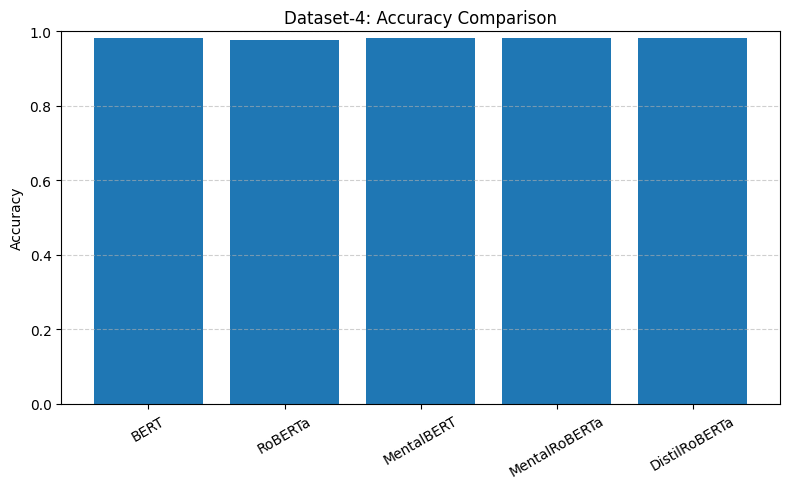

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(len(df_results_ds4["Model"]))

plt.figure(figsize=(8,5))
plt.bar(x, df_results_ds4["Accuracy"])
plt.xticks(x, df_results_ds4["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Dataset-4: Accuracy Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


ROC-AUC Graph

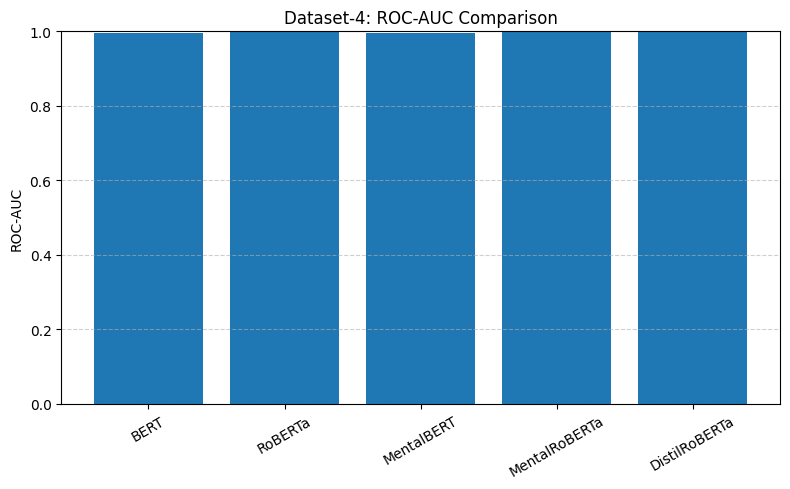

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(x, df_results_ds4["ROC-AUC"])
plt.xticks(x, df_results_ds4["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Dataset-4: ROC-AUC Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Accuracy vs ROC-AUC

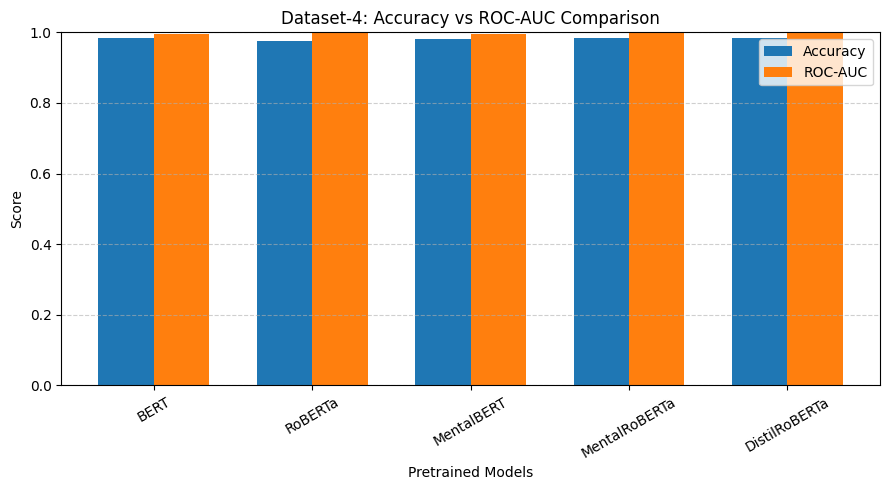

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_results_ds4["Model"]))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, df_results_ds4["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, df_results_ds4["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, df_results_ds4["Model"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Pretrained Models")
plt.title("Dataset-4: Accuracy vs ROC-AUC Comparison")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Dataset 5 libraries import

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, roc_auc_score
from torch.cuda.amp import autocast, GradScaler


Dataset 5

In [ ]:
import pandas as pd

df5 = pd.read_csv("/content/drive/MyDrive/dataset5.csv")  # adjust path if needed
print(df5.shape)
print(df5.columns)
df5.head()


(1191, 6)
Index(['Unnamed: 0', 'ID', 'Tweet', 'Affect Dimension', 'Intensity Score',
       'target'],
      dtype='object')


,Unnamed: 0,ID,Tweet,Affect Dimension,Intensity Score,target
0,0,2018-En-03332,Be happy. Be confident. Be kind.\n\n #Kissable...,joy,0.661,0
1,1,2018-En-01146,@queenjlouise @mamaw_gereck awe thanks 😊,fear,0.089,0
2,2,2018-En-02249,@Ithika Loving it! 😂,joy,0.813,0
3,3,2018-En-00192,@mir_btc Eherium should make everybody happy,joy,0.515,0
4,4,2018-En-03117,Shitty is the worst feeling ever #depressed #a...,sadness,0.895,1


Labels

In [ ]:
text_column  = "Tweet"
label_column = "target"


In [ ]:
print(df5.columns)


Index(['Unnamed: 0', 'ID', 'Tweet', 'Affect Dimension', 'Intensity Score',
       'target'],
      dtype='object')


In [ ]:
print(df5.columns)


Index(['Unnamed: 0', 'ID', 'Tweet', 'Affect Dimension', 'Intensity Score',
       'target'],
      dtype='object')


In [ ]:
print(df5[label_column].value_counts())


target
0    1131
1      60
Name: count, dtype: int64


In [ ]:
df5 = df5[[text_column, label_column]].dropna()
df5[label_column] = df5[label_column].astype(int)


STEP 2 — Device & FP16 Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

use_fp16 = torch.cuda.is_available()
scaler = GradScaler(enabled=use_fp16)


Using device: cuda


/tmp/ipython-input-3445361511.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_fp16)


STEP 3 — GPU-FRIENDLY Dataset Class

In [ ]:
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


Train / Test Split  

In [ ]:
X5 = df5[text_column].tolist()
y5 = df5[label_column].tolist()

from sklearn.model_selection import train_test_split

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5,
    y5,
    test_size=0.2,
    random_state=42,
    stratify=y5   # 🔥 very important for imbalance
)

print("Train size:", len(X5_train))
print("Test size:", len(X5_test))


Train size: 952
Test size: 239


STEP 4 — Models List

In [ ]:
models_list = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "MentalBERT": "mental/mental-bert-base-uncased",
    "MentalRoBERTa": "mental/mental-roberta-base",
    "DistilRoBERTa": "distilroberta-base"
}


STEP 5 — CORE TRAINING (LOW GPU, 20 Epochs)

In [ ]:
from torch.cuda.amp import autocast, GradScaler

results_ds5 = []
scaler = GradScaler()

for model_name, checkpoint in models_list.items():

    print("\n" + "="*60)
    print(f"Training & Evaluating {model_name} on Dataset-5")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    # 🔒 Freeze encoder (saves GPU & time)
    for param in model.base_model.parameters():
        param.requires_grad = False

    train_ds = DepressionDataset(X5_train, y5_train, tokenizer)
    test_ds  = DepressionDataset(X5_test,  y5_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=8)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-5
    )

    epochs = 20
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ---------- Evaluation ----------
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds5.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })


/tmp/ipython-input-1291719019.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Training & Evaluating BERT on Dataset-5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1291719019.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/20 | Loss: 0.8648
Epoch 2/20 | Loss: 0.4214
Epoch 3/20 | Loss: 0.2848
Epoch 4/20 | Loss: 0.2397
Epoch 5/20 | Loss: 0.2245
Epoch 6/20 | Loss: 0.2153
Epoch 7/20 | Loss: 0.2137
Epoch 8/20 | Loss: 0.2118
Epoch 9/20 | Loss: 0.2060
Epoch 10/20 | Loss: 0.2058
Epoch 11/20 | Loss: 0.2102
Epoch 12/20 | Loss: 0.2026
Epoch 13/20 | Loss: 0.2048
Epoch 14/20 | Loss: 0.2056
Epoch 15/20 | Loss: 0.2071
Epoch 16/20 | Loss: 0.2053
Epoch 17/20 | Loss: 0.2030
Epoch 18/20 | Loss: 0.2060
Epoch 19/20 | Loss: 0.2035
Epoch 20/20 | Loss: 0.2040


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       227
           1       0.00      0.00      0.00        12

    accuracy                           0.95       239
   macro avg       0.47      0.50      0.49       239
weighted avg       0.90      0.95      0.93       239

ROC-AUC: 0.9397944199706314

Training & Evaluating DistilRoBERTa on Dataset-5


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1291719019.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/20 | Loss: 0.3728
Epoch 2/20 | Loss: 0.2283
Epoch 3/20 | Loss: 0.2081
Epoch 4/20 | Loss: 0.2086
Epoch 5/20 | Loss: 0.2083
Epoch 6/20 | Loss: 0.2046
Epoch 7/20 | Loss: 0.1996
Epoch 8/20 | Loss: 0.1912
Epoch 9/20 | Loss: 0.2022
Epoch 10/20 | Loss: 0.1959
Epoch 11/20 | Loss: 0.1890
Epoch 12/20 | Loss: 0.1914
Epoch 13/20 | Loss: 0.1913
Epoch 14/20 | Loss: 0.1863
Epoch 15/20 | Loss: 0.1779
Epoch 16/20 | Loss: 0.1814
Epoch 17/20 | Loss: 0.1801
Epoch 18/20 | Loss: 0.1806
Epoch 19/20 | Loss: 0.1703
Epoch 20/20 | Loss: 0.1698
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       227
           1       0.00      0.00      0.00        12

    accuracy                           0.95       239
   macro avg       0.47      0.50      0.49       239
weighted avg       0.90      0.95      0.93       239

ROC-AUC: 0.9151982378854625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Required lib imports

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, roc_auc_score


30 epochs

In [ ]:
results_ds5 = []

scaler = GradScaler()  # for mixed precision

for model_name, checkpoint in models_list.items():

    print("\n" + "="*65)
    print(f"Training & Evaluating {model_name} on Dataset-5 (30 Epochs)")
    print("="*65)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=2
    ).to(device)

    # 🔒 Freeze base model layers (GPU saving)
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Dataset & Dataloader
    train_ds = DepressionDataset(X5_train, y5_train, tokenizer)
    test_ds  = DepressionDataset(X5_test,  y5_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=8)

    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

    # ---------------- TRAIN ----------------
    epochs = 30
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with autocast():  # 🔥 mixed precision
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # ---------------- EVALUATION ----------------
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = sum(p == t for p, t in zip(preds, true)) / len(true)
    auc = roc_auc_score(true, probs)

    print(classification_report(true, preds))
    print("ROC-AUC:", auc)

    results_ds5.append({
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })


/tmp/ipython-input-1066720898.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision



Training & Evaluating BERT on Dataset-5 (30 Epochs)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1066720898.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # 🔥 mixed precision


Epoch 01/30 | Loss: 0.5859
Epoch 02/30 | Loss: 0.3130
Epoch 03/30 | Loss: 0.2492
Epoch 04/30 | Loss: 0.2214
Epoch 05/30 | Loss: 0.2164
Epoch 06/30 | Loss: 0.2133
Epoch 07/30 | Loss: 0.2118
Epoch 08/30 | Loss: 0.2105
Epoch 09/30 | Loss: 0.2105
Epoch 10/30 | Loss: 0.2066
Epoch 11/30 | Loss: 0.2067
Epoch 12/30 | Loss: 0.2104
Epoch 13/30 | Loss: 0.2069
Epoch 14/30 | Loss: 0.2086
Epoch 15/30 | Loss: 0.2080
Epoch 16/30 | Loss: 0.2066
Epoch 17/30 | Loss: 0.2013
Epoch 18/30 | Loss: 0.2034
Epoch 19/30 | Loss: 0.2003
Epoch 20/30 | Loss: 0.2043
Epoch 21/30 | Loss: 0.2055
Epoch 22/30 | Loss: 0.2052
Epoch 23/30 | Loss: 0.2035
Epoch 24/30 | Loss: 0.2030
Epoch 25/30 | Loss: 0.2038
Epoch 26/30 | Loss: 0.2038
Epoch 27/30 | Loss: 0.2027
Epoch 28/30 | Loss: 0.2004
Epoch 29/30 | Loss: 0.1983
Epoch 30/30 | Loss: 0.2010


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1066720898.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # 🔥 mixed precision


Epoch 01/30 | Loss: 0.3355
Epoch 02/30 | Loss: 0.2359
Epoch 03/30 | Loss: 0.2174
Epoch 04/30 | Loss: 0.2169
Epoch 05/30 | Loss: 0.2093
Epoch 06/30 | Loss: 0.2065
Epoch 07/30 | Loss: 0.1935
Epoch 08/30 | Loss: 0.1891
Epoch 09/30 | Loss: 0.1921
Epoch 10/30 | Loss: 0.1816
Epoch 11/30 | Loss: 0.1776
Epoch 12/30 | Loss: 0.1746
Epoch 13/30 | Loss: 0.1712
Epoch 14/30 | Loss: 0.1618
Epoch 15/30 | Loss: 0.1644
Epoch 16/30 | Loss: 0.1541
Epoch 17/30 | Loss: 0.1540
Epoch 18/30 | Loss: 0.1472
Epoch 19/30 | Loss: 0.1391
Epoch 20/30 | Loss: 0.1427
Epoch 21/30 | Loss: 0.1376
Epoch 22/30 | Loss: 0.1335
Epoch 23/30 | Loss: 0.1302
Epoch 24/30 | Loss: 0.1249
Epoch 25/30 | Loss: 0.1202
Epoch 26/30 | Loss: 0.1189
Epoch 27/30 | Loss: 0.1173
Epoch 28/30 | Loss: 0.1089
Epoch 29/30 | Loss: 0.1086
Epoch 30/30 | Loss: 0.1045
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       227
           1       1.00      0.08      0.15        12

    accuracy              

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1066720898.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # 🔥 mixed precision


Epoch 01/30 | Loss: 0.3138
Epoch 02/30 | Loss: 0.2175
Epoch 03/30 | Loss: 0.2122
Epoch 04/30 | Loss: 0.2088
Epoch 05/30 | Loss: 0.2102
Epoch 06/30 | Loss: 0.2013
Epoch 07/30 | Loss: 0.2018
Epoch 08/30 | Loss: 0.1947
Epoch 09/30 | Loss: 0.2007
Epoch 10/30 | Loss: 0.1944
Epoch 11/30 | Loss: 0.1961
Epoch 12/30 | Loss: 0.1870
Epoch 13/30 | Loss: 0.1884
Epoch 14/30 | Loss: 0.1842
Epoch 15/30 | Loss: 0.1851
Epoch 16/30 | Loss: 0.1779
Epoch 17/30 | Loss: 0.1792
Epoch 18/30 | Loss: 0.1735
Epoch 19/30 | Loss: 0.1718
Epoch 20/30 | Loss: 0.1690
Epoch 21/30 | Loss: 0.1684
Epoch 22/30 | Loss: 0.1672
Epoch 23/30 | Loss: 0.1612
Epoch 24/30 | Loss: 0.1593
Epoch 25/30 | Loss: 0.1596
Epoch 26/30 | Loss: 0.1553
Epoch 27/30 | Loss: 0.1481
Epoch 28/30 | Loss: 0.1490
Epoch 29/30 | Loss: 0.1456
Epoch 30/30 | Loss: 0.1447
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       227
           1       0.00      0.00      0.00        12

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


result table

In [ ]:
import pandas as pd

df_results_ds5 = pd.DataFrame(results_ds5)
df_results_ds5


,Model,Accuracy,ROC-AUC
0,BERT,0.949791,0.719163
1,RoBERTa,0.949791,0.929148
2,MentalBERT,0.949791,0.812041
3,MentalRoBERTa,0.953975,0.941630
4,DistilRoBERTa,0.949791,0.930617


Accuracy bargraph

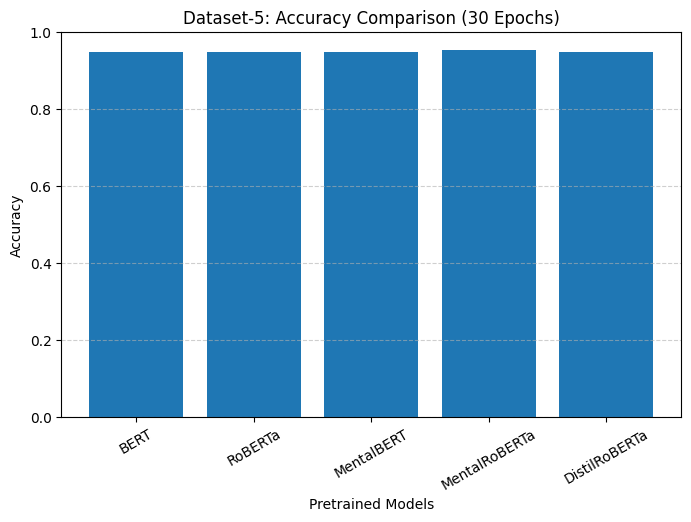

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = df_results_ds5["Model"]
accuracy = df_results_ds5["Accuracy"]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.ylim(0, 1)
plt.xlabel("Pretrained Models")
plt.ylabel("Accuracy")
plt.title("Dataset-5: Accuracy Comparison (30 Epochs)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Roc - aug bar graph

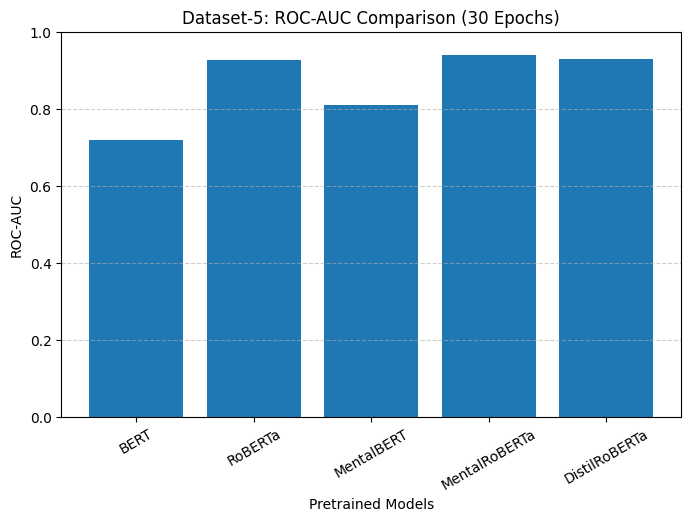

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
roc_auc = df_results_ds5["ROC-AUC"]

plt.figure(figsize=(8,5))
plt.bar(models, roc_auc)
plt.ylim(0, 1)
plt.xlabel("Pretrained Models")
plt.ylabel("ROC-AUC")
plt.title("Dataset-5: ROC-AUC Comparison (30 Epochs)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Comparision of Accuracy vs Roc - aug graph

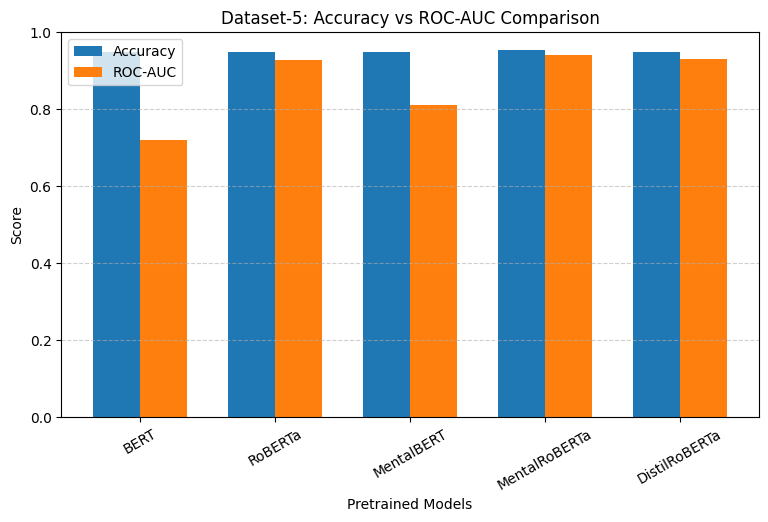

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, roc_auc, width, label="ROC-AUC")

plt.xticks(x, models, rotation=30)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Pretrained Models")
plt.title("Dataset-5: Accuracy vs ROC-AUC Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Dataset 3
Dynamic Transformer + TextGCN Training

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.9.0+cu126
True


In [ ]:
!pip install -q transformers==4.39.3
!pip install -q torch-geometric
!pip install -q networkx


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.2 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.39.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y sentence-transformers
!pip install -U transformers


Found existing installation: sentence-transformers 5.2.2
Uninstalling sentence-transformers-5.2.2:
  Successfully uninstalled sentence-transformers-5.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.39.3
    Uninstalling transformers-4.39.3:
      Successfully uninstalled transformers-4.39.3


In [ ]:
import transformers
print(transformers.__version__)


5.1.0


In [ ]:
import torch
import transformers
import torch_geometric
import networkx

print("✅ Everything working perfectly")


✅ Everything working perfectly


In [ ]:
!pip uninstall -y sentence-transformers
!pip install -U transformers
!pip install -U torch-geometric networkx


In [ ]:
import transformers
import torch_geometric
import networkx

print("✅ Environment ready")


✅ Environment ready


In [ ]:
!pip install -q transformers==4.39.3
!pip install -q torch-geometric
!pip install -q networkx


In [ ]:
!pip uninstall -y transformers huggingface_hub tokenizers
!pip install -q transformers==4.39.3


Found existing installation: transformers 4.39.3
Uninstalling transformers-4.39.3:
  Successfully uninstalled transformers-4.39.3
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
Found existing installation: tokenizers 0.15.2
Uninstalling tokenizers-0.15.2:
  Successfully uninstalled tokenizers-0.15.2


In [ ]:
import transformers
print(transformers.__version__)


4.39.3


Libraries importing

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel

import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv

print("✅ All imports successful")


✅ All imports successful


Dataset Loading

In [ ]:
# change file path if needed
df = pd.read_csv("/content/drive/MyDrive/dataset3.csv")

print(df.head())
print(df.columns)


                                                text     label
0  He said he had not felt that way before, sugge...      mild
1  Hey there r/assistance, Not sure if this is th...   minimum
2  My mom then hit me with the newspaper and it s...   minimum
3  until i met my new boyfriend, he is amazing, h...      mild
4  October is Domestic Violence Awareness Month a...  moderate
Index(['text', 'label'], dtype='object')


In [ ]:
text_column = "text"      # change if different
label_column = "label"   # change if different

df = df[[text_column, label_column]].dropna()

print(df[label_column].value_counts())


label
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64


Train / Test split

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df[text_column].tolist(),
    df[label_column].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df[label_column]
)

print("Train:", len(train_texts))
print("Test :", len(test_texts))


Train: 2842
Test : 711


Load Transformer(MentalBert)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer = AutoModel.from_pretrained(MODEL_NAME).to(device)

print("✅ Transformer ready")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Transformer ready


STEP 7 — Convert Text → Embeddings

In [ ]:
def get_embeddings(texts, batch_size=16):
    all_embeddings = []

    transformer.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
                max_length=128
            ).to(device)

            outputs = transformer(**enc)

            # CLS token embedding
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)


Run for Train and Test

In [ ]:
train_embeddings = get_embeddings(train_texts)
test_embeddings  = get_embeddings(test_texts)

print(train_embeddings.shape)


100%|██████████| 45/45 [00:04<00:00,  9.15it/s]

torch.Size([2842, 768])


STEP 8 — Dynamic Graph Construction
Code — Build Edges

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# convert tensor → numpy
emb_np = train_embeddings.numpy()

# similarity matrix
sim_matrix = cosine_similarity(emb_np)

print("Similarity matrix shape:", sim_matrix.shape)


Similarity matrix shape: (2842, 2842)


Now Create Edges

In [ ]:
threshold = 0.8   # can tune later

edges = []

for i in range(len(sim_matrix)):
    for j in range(len(sim_matrix)):
        if i != j and sim_matrix[i][j] > threshold:
            edges.append([i, j])

print("Total edges:", len(edges))


Total edges: 1546210


Convert Edges -> Tensor

In [ ]:
import torch

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print(edge_index.shape)


torch.Size([2, 1546210])


Step - 9  Convert labels into integers

In [ ]:
print(set(train_labels))


{'moderate', 'minimum', 'severe', 'mild'}


Correct label conversion code

In [ ]:
label_map = {
    "minimum": 0,
    "mild": 0,
    "moderate": 1,
    "severe": 1
}

train_labels = [label_map[str(l).lower()] for l in train_labels]


In [ ]:
print(set(train_labels))


{0, 1}


Create the tensor

In [ ]:
y = torch.tensor(train_labels, dtype=torch.long)


Now Build Graph Object

In [ ]:
from torch_geometric.data import Data

x = train_embeddings
data = Data(x=x, edge_index=edge_index, y=y)

print(data)


Data(x=[2842, 768], edge_index=[2, 1546210], y=[2842])


Step 10 - Build The TextGCN Network

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class TextGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(TextGCN, self).__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)

        self.dropout = 0.3

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)

        return x


Step 11 - Initialize Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextGCN(
    input_dim=train_embeddings.shape[1],   # 768
    hidden_dim=128,
    num_classes=2
).to(device)

data = data.to(device)

print(model)


TextGCN(
  (conv1): GCNConv(768, 128)
  (conv2): GCNConv(128, 2)
)


Step 12 Optimizer & Loss

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()


Step 13 Training Loop 30 epochs

In [ ]:
epochs = 30   # you can change

model.train()

for epoch in range(epochs):
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(out, data.y)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 5/30, Loss: 0.4650
Epoch 10/30, Loss: 0.4783
Epoch 15/30, Loss: 0.4455
Epoch 20/30, Loss: 0.4276
Epoch 25/30, Loss: 0.4288
Epoch 30/30, Loss: 0.4261


Step 14 Evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

model.eval()

with torch.no_grad():
    logits = model(data.x, data.edge_index)

    preds = torch.argmax(logits, dim=1).cpu().numpy()
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    true = data.y.cpu().numpy()

print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs))


              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2301
           1       0.47      0.21      0.29       541

    accuracy                           0.81      2842
   macro avg       0.65      0.58      0.59      2842
weighted avg       0.77      0.81      0.77      2842

ROC-AUC: 0.76436066935456


results

In [ ]:
models = ["Transformer + TextGCN"]
accuracy = [0.81]        # replace if updated
roc_auc = [0.764]        # replace if updated


Accuracy bargraph

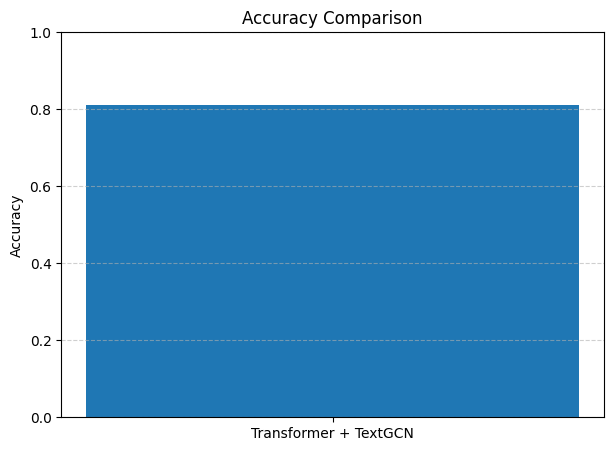

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Roc - auc graph

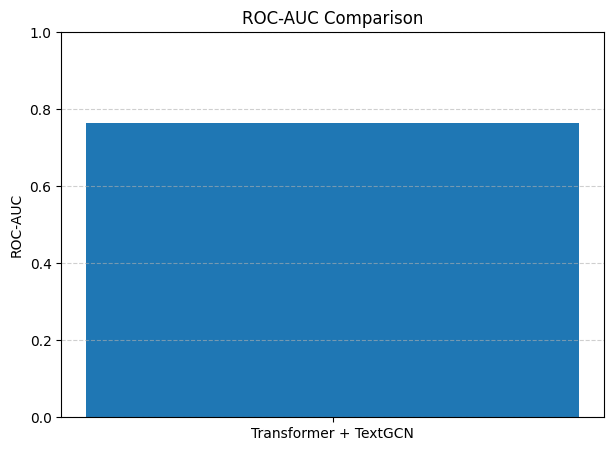

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.bar(models, roc_auc)
plt.ylim(0,1)
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Accuracy vs roc - auc graph

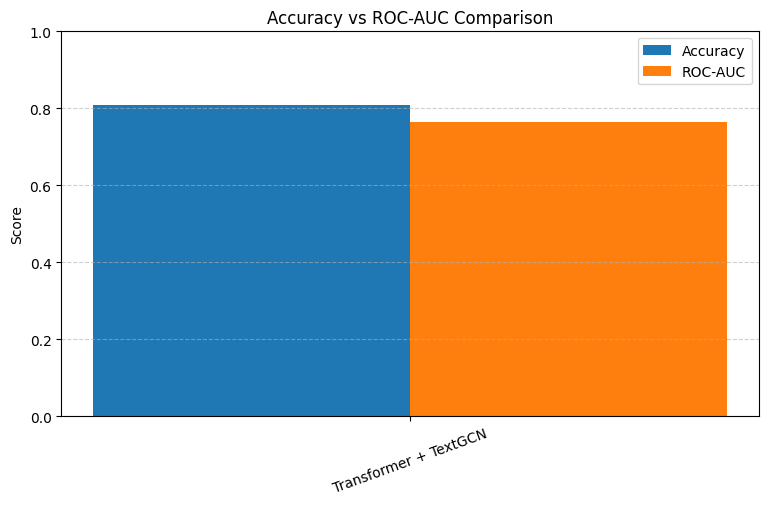

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, roc_auc, width, label="ROC-AUC")

plt.xticks(x, models, rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Accuracy vs ROC-AUC Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Comparison of all 5 datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# DATASET-1
# ===============================
results_df = pd.DataFrame({
    "Model": ["BERT","RoBERTa","MentalBERT","MentalRoBERTa","DistilRoBERTa"],
    "Accuracy": [0.97,0.97,0.98,0.97,0.99],
    "ROC-AUC": [0.9599,0.9915,0.9622,0.9827,0.8664]
})

# ===============================
# DATASET-2
# ===============================
df_results_ds2 = pd.DataFrame({
    "Model": ["BERT","RoBERTa","MentalBERT","MentalRoBERTa","DistilRoBERTa"],
    "Accuracy": [0.980,0.970,0.965,0.945,0.950],
    "ROC-AUC": [0.9998,0.9889,0.9960,0.9854,0.9885]
})

# ===============================
# DATASET-3
# ===============================
df_results_ds3 = pd.DataFrame({
    "Model": ["BERT","RoBERTa","MentalBERT","MentalRoBERTa","DistilRoBERTa"],
    "Accuracy": [0.822785,0.827004,0.797468,0.810127,0.798875],
    "ROC-AUC": [0.785674,0.772312,0.780710,0.786195,0.775386]
})

# ===============================
# DATASET-4
# ===============================
df_results_ds4 = pd.DataFrame({
    "Model": ["BERT","RoBERTa","MentalBERT","MentalRoBERTa","DistilRoBERTa"],
    "Accuracy": [0.982547,0.975436,0.981254,0.982547,0.982547],
    "ROC-AUC": [0.996687,0.997337,0.996512,0.997649,0.997461]
})

# ===============================
# DATASET-5
# ===============================
df_results_ds5 = pd.DataFrame({
    "Model": ["BERT","RoBERTa","MentalBERT","MentalRoBERTa","DistilRoBERTa"],
    "Accuracy": [0.949791,0.949791,0.949791,0.953975,0.949791],
    "ROC-AUC": [0.719163,0.929148,0.812041,0.941630,0.930617]
})

print("✅ All dataset tables recreated successfully.")

✅ All dataset tables recreated successfully.



=========== MASTER RESULT TABLE ===========



,Model,Accuracy,ROC-AUC,Dataset
0,BERT,0.970000,0.959900,Dataset-1
1,RoBERTa,0.970000,0.991500,Dataset-1
2,MentalBERT,0.980000,0.962200,Dataset-1
3,MentalRoBERTa,0.970000,0.982700,Dataset-1
4,DistilRoBERTa,0.990000,0.866400,Dataset-1
5,BERT,0.980000,0.999800,Dataset-2
6,RoBERTa,0.970000,0.988900,Dataset-2
7,MentalBERT,0.965000,0.996000,Dataset-2
8,MentalRoBERTa,0.945000,0.985400,Dataset-2
9,DistilRoBERTa,0.950000,0.988500,Dataset-2



=========== BEST MODEL PER DATASET ===========



,Model,Accuracy,ROC-AUC,Dataset
4,DistilRoBERTa,0.990000,0.866400,Dataset-1
5,BERT,0.980000,0.999800,Dataset-2
11,RoBERTa,0.827004,0.772312,Dataset-3
15,BERT,0.982547,0.996687,Dataset-4
23,MentalRoBERTa,0.953975,0.941630,Dataset-5



=========== AVERAGE PERFORMANCE (ALL DATASETS) ===========



,Accuracy,ROC-AUC
Model,,
BERT,0.941025,0.892245
RoBERTa,0.938446,0.935839
MentalBERT,0.934703,0.909493
DistilRoBERTa,0.934243,0.911673
MentalRoBERTa,0.932330,0.938715


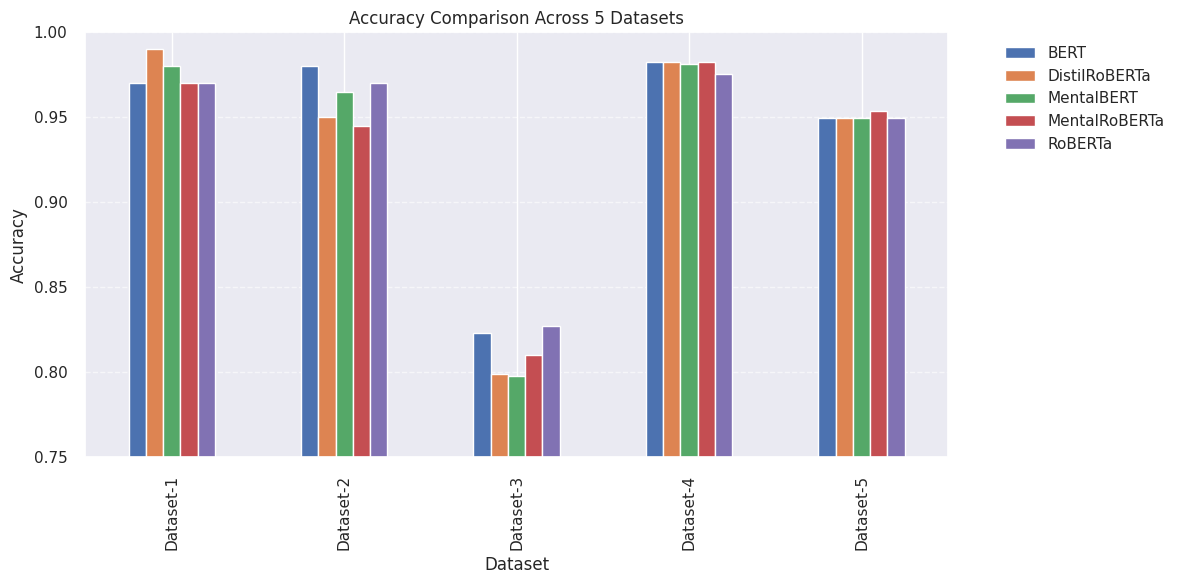

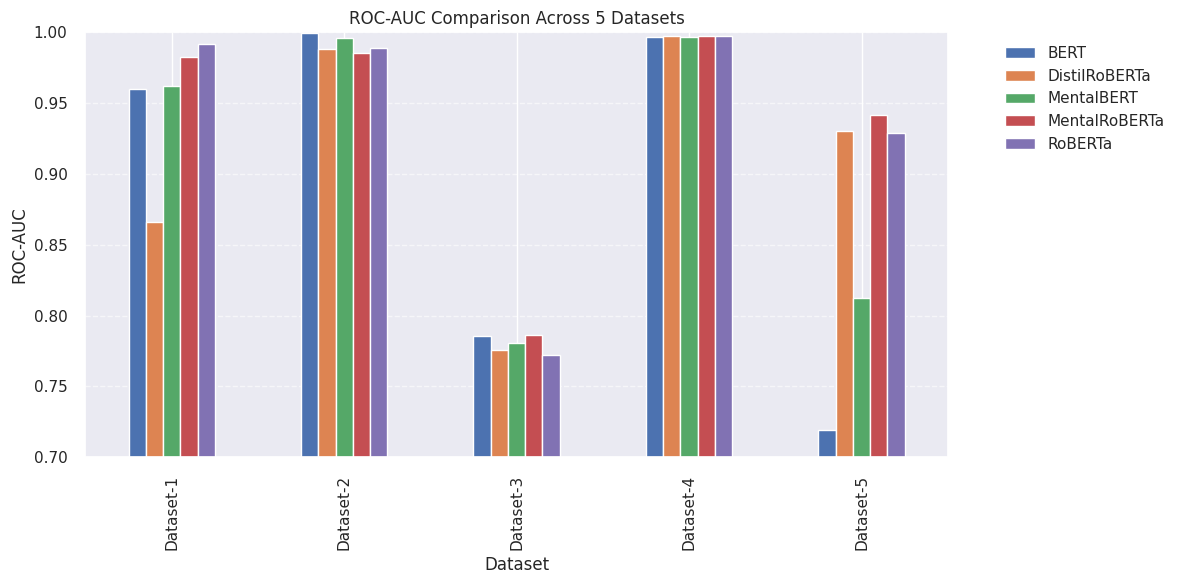

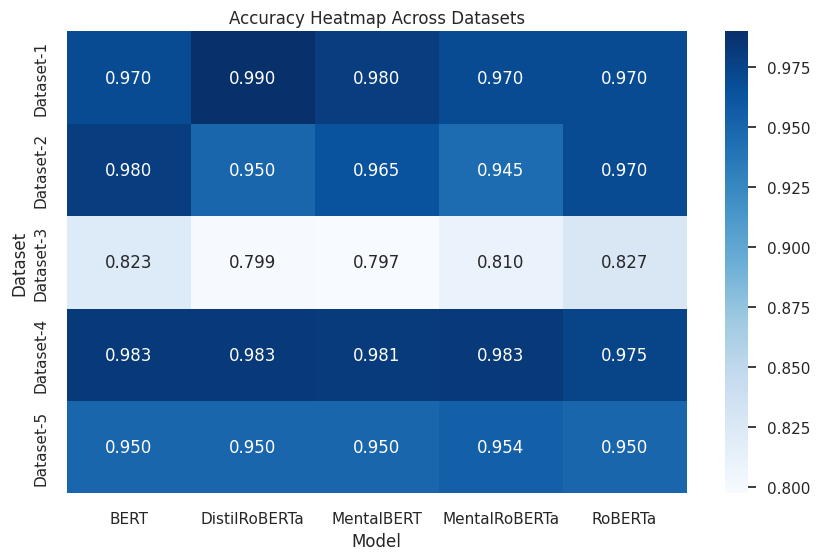

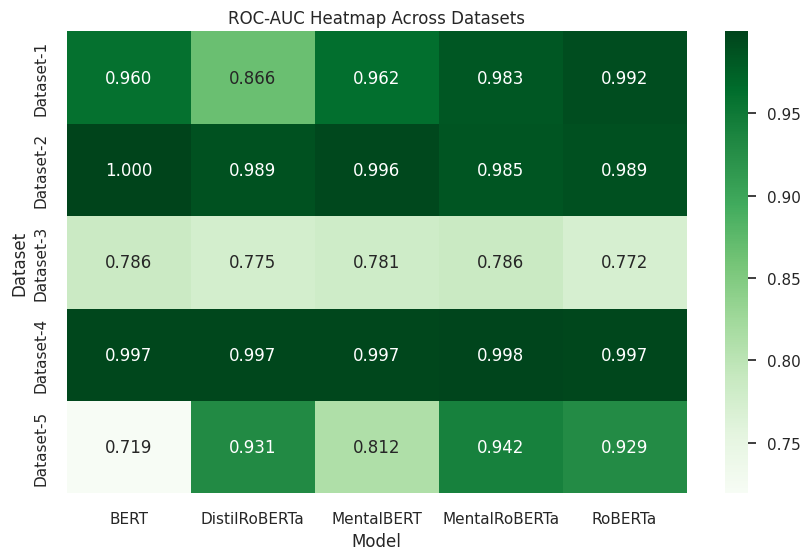


✅ All cross-dataset comparison graphs generated successfully!


In [ ]:
# ==========================================================
# 🔥 MASTER CROSS-DATASET COMPARISON
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.0)

# ----------------------------------------------------------
# STEP 1: Standardize column names
# ----------------------------------------------------------

results_df = results_df.rename(columns={"ROC_AUC": "ROC-AUC"})
df_results_ds2 = df_results_ds2.rename(columns={"ROC_AUC": "ROC-AUC"})
df_results_ds3 = df_results_ds3.rename(columns={"ROC_AUC": "ROC-AUC"})
df_results_ds4 = df_results_ds4.rename(columns={"ROC_AUC": "ROC-AUC"})
df_results_ds5 = df_results_ds5.rename(columns={"ROC_AUC": "ROC-AUC"})

# ----------------------------------------------------------
# STEP 2: Add Dataset column
# ----------------------------------------------------------

results_df["Dataset"] = "Dataset-1"
df_results_ds2["Dataset"] = "Dataset-2"
df_results_ds3["Dataset"] = "Dataset-3"
df_results_ds4["Dataset"] = "Dataset-4"
df_results_ds5["Dataset"] = "Dataset-5"

# ----------------------------------------------------------
# STEP 3: Combine all datasets
# ----------------------------------------------------------

all_results = pd.concat([
    results_df,
    df_results_ds2,
    df_results_ds3,
    df_results_ds4,
    df_results_ds5
], ignore_index=True)

print("\n=========== MASTER RESULT TABLE ===========\n")
display(all_results)

# ----------------------------------------------------------
# STEP 4: Best Model per Dataset
# ----------------------------------------------------------

best_models = all_results.loc[
    all_results.groupby("Dataset")["Accuracy"].idxmax()
]

print("\n=========== BEST MODEL PER DATASET ===========\n")
display(best_models)

# ----------------------------------------------------------
# STEP 5: Average Performance Across All Datasets
# ----------------------------------------------------------

avg_performance = all_results.groupby("Model")[["Accuracy","ROC-AUC"]].mean()
avg_performance = avg_performance.sort_values("Accuracy", ascending=False)

print("\n=========== AVERAGE PERFORMANCE (ALL DATASETS) ===========\n")
display(avg_performance)

# ----------------------------------------------------------
# STEP 6: Accuracy Comparison Across Datasets
# ----------------------------------------------------------

pivot_acc = all_results.pivot(index="Dataset", columns="Model", values="Accuracy")

pivot_acc.plot(kind="bar", figsize=(12,6))
plt.title("Accuracy Comparison Across 5 Datasets")
plt.ylabel("Accuracy")
plt.ylim(0.75,1.0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 7: ROC-AUC Comparison Across Datasets
# ----------------------------------------------------------

pivot_roc = all_results.pivot(index="Dataset", columns="Model", values="ROC-AUC")

pivot_roc.plot(kind="bar", figsize=(12,6))
plt.title("ROC-AUC Comparison Across 5 Datasets")
plt.ylabel("ROC-AUC")
plt.ylim(0.70,1.0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 8: Heatmaps (Very Strong for PPT)
# ----------------------------------------------------------

plt.figure(figsize=(10,6))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="Blues")
plt.title("Accuracy Heatmap Across Datasets")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(pivot_roc, annot=True, fmt=".3f", cmap="Greens")
plt.title("ROC-AUC Heatmap Across Datasets")
plt.show()

print("\n✅ All cross-dataset comparison graphs generated successfully!")